# FINLORA EXPLORATORY DATA ANALYSIS

*Description:* I dug through the cleaned dataset to understand the fraud signal before we do any serious modelling, and to have the numbers straight for stakeholders. Nothing here is final — it's the story the data tells so I can defend the model later.

I wrote this the way I talk to another mid-level data person: plain words, honest findings, no pretend precision.

In [1]:
# standard imports so I can poke at the data and draw the charts below
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

In [2]:
# load the cleaned dataset that came out of the cleaning notebook
df = pd.read_parquet("../data_assets/cleaned/finlora_cleaned.parquet")
print(f"rows: {len(df):,} | cols: {df.shape[1]} | fraud: {df.is_fraud.mean()*100:.2f}%")
print()
# quick look at column types so I know what I'm working with
df.dtypes.value_counts()

rows: 11,200 | cols: 29 | fraud: 8.88%



float64                9
str                    8
bool                   4
int64                  4
string                 2
datetime64[us, UTC]    1
boolean                1
Name: count, dtype: int64

### Where I run into trouble
Quick context before charts: this is heavily imbalanced fraud data, so I'll read every percentage *against* the 8.88% baseline, not as absolute truth.

In [3]:
# colours I'll reuse everywhere so fraud always reads the same way
LEGIT, FRAUD, NEUTRAL = "#2563eb", "#dc2626", "#94a3b8"

sns.set_theme(
    style="white",
    rc={
        "axes.edgecolor": "#cbd5e1",
        "axes.linewidth": 0.8,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)
plt.rcParams["figure.autolayout"] = True

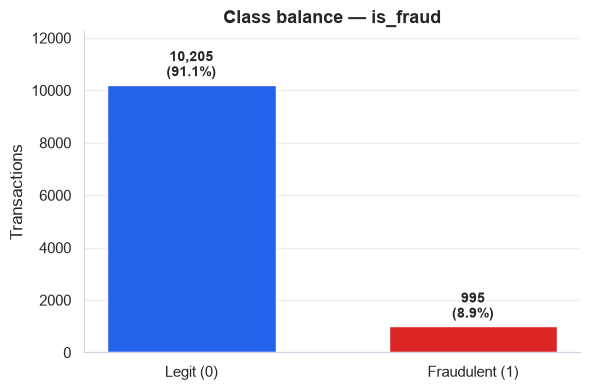

In [4]:
# how bad is the imbalance? if I can't see 995 frauds clearly, every model metric needs care
balance = df.is_fraud.value_counts().reindex([0, 1], fill_value=0)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Legit (0)", "Fraudulent (1)"], balance.values,
              color=[LEGIT, FRAUD], width=0.60)
for bar, val in zip(bars, balance.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 180,
            f"{val:,}\n({val/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_ylim(0, balance.max()*1.2)
ax.set_ylabel("Transactions")
ax.set_title("Class balance — is_fraud")
ax.grid(axis="y", alpha=0.3)
plt.show()

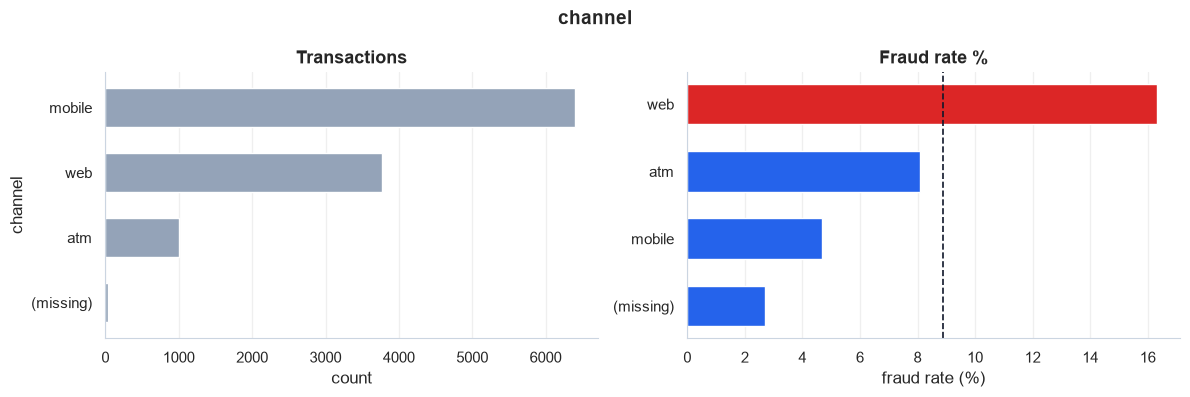

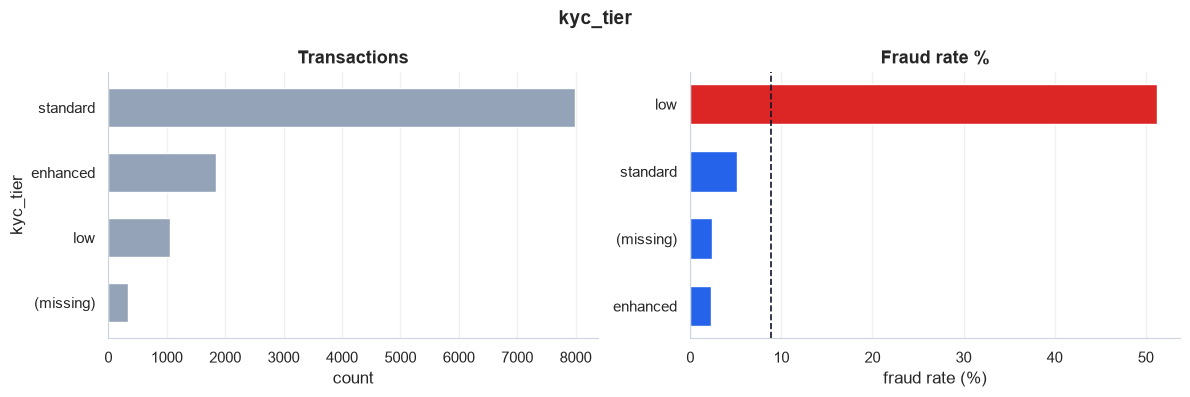

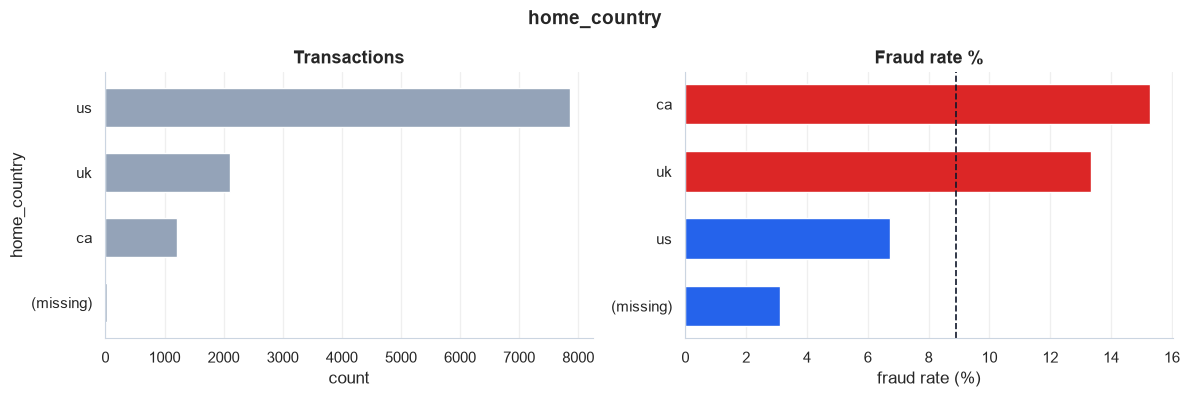

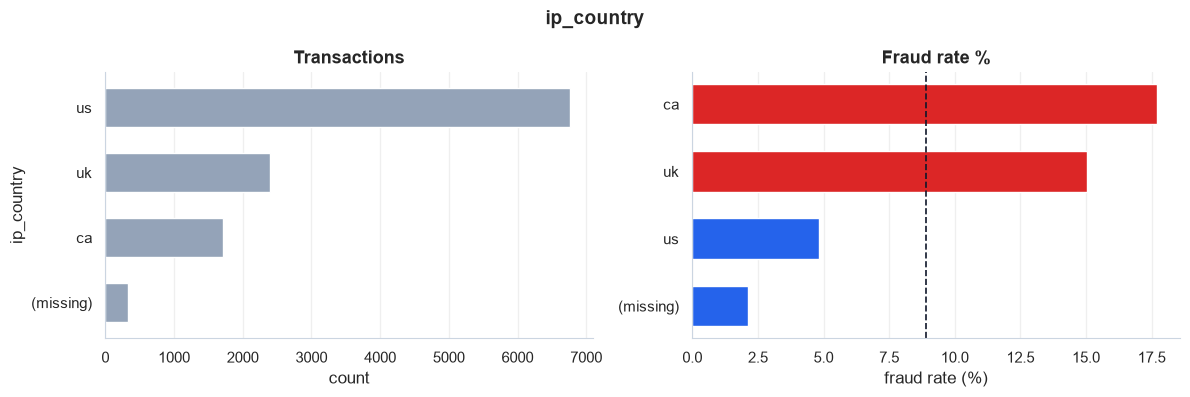

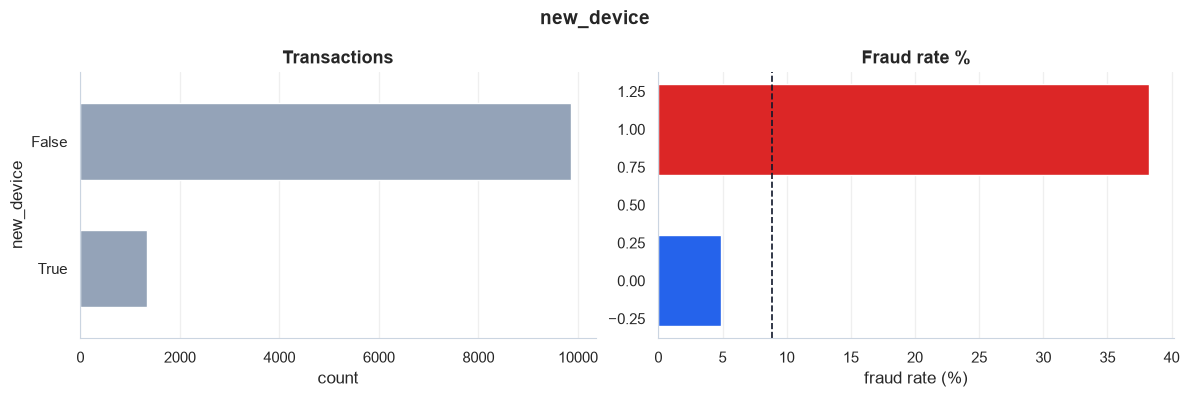

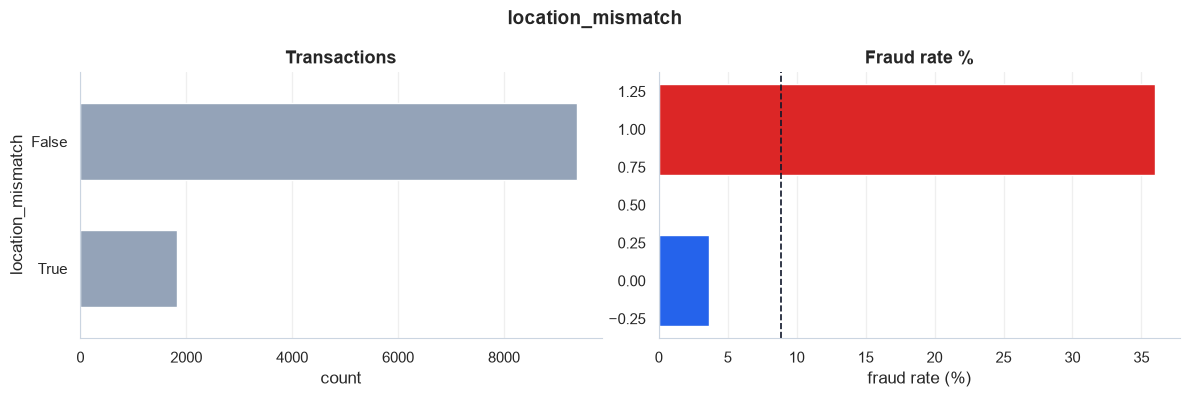

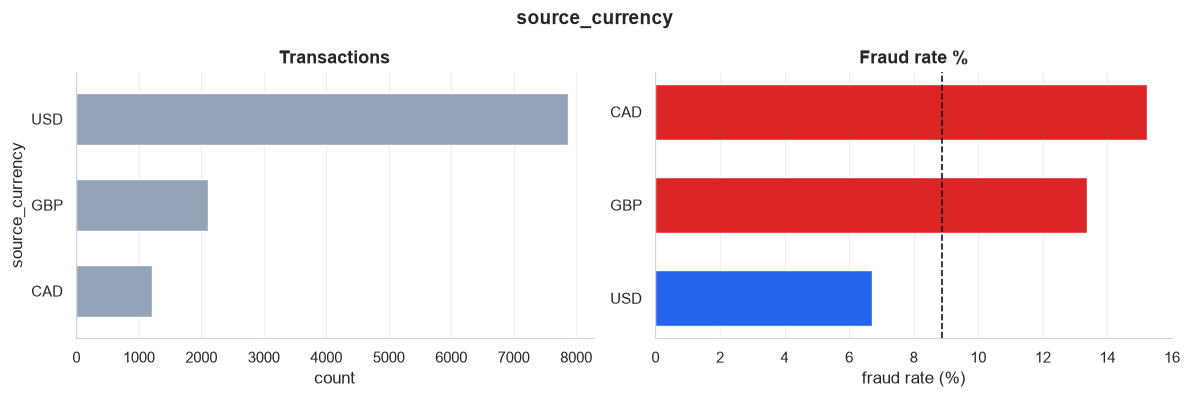

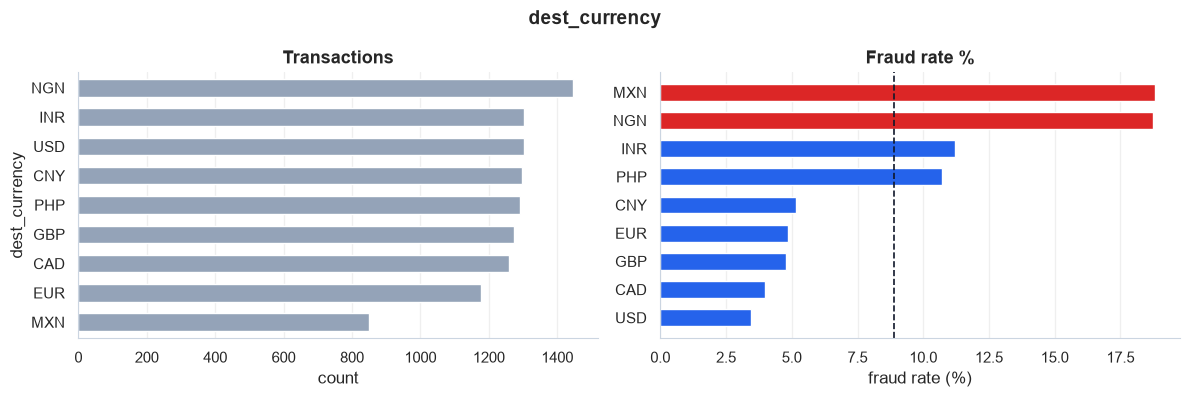

In [5]:
# categories: fraud rate per level -- the first place the signal usually hides
def cat_chart(col):
    t = (df.groupby(col, dropna=False)["is_fraud"]
           .agg(n="count", rate="mean")
           .reset_index()
           .fillna({col: "(missing)"})
           .set_index(col))

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(col, fontweight="bold", fontsize=14)

    t.sort_values("n").plot.barh(ax=ax0, y="n", color=NEUTRAL, legend=False, width=0.6)
    ax0.set_title("Transactions")
    ax0.set_xlabel("count")
    ax0.grid(axis="x", alpha=0.3)

    t2 = t.sort_values("rate")
    colors = [FRAUD if r >= df.is_fraud.mean()*1.5 else LEGIT for r in t2["rate"]]
    ax1.barh(t2.index, t2["rate"]*100, color=colors, height=0.6)
    ax1.axvline(df.is_fraud.mean()*100, ls="--", color="#0f172a", lw=1.2)
    ax1.set_title("Fraud rate %")
    ax1.set_xlabel("fraud rate (%)")
    ax1.grid(axis="x", alpha=0.3)
    plt.show()

for col in ["channel", "kyc_tier", "home_country", "ip_country",
            "new_device", "location_mismatch", "source_currency", "dest_currency"]:
    cat_chart(col)

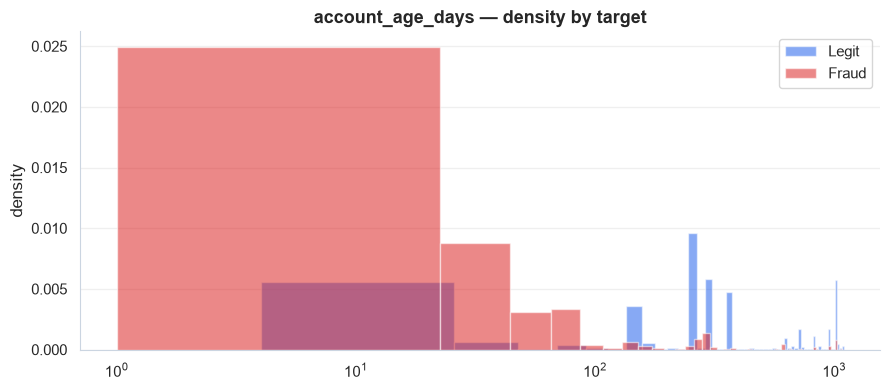

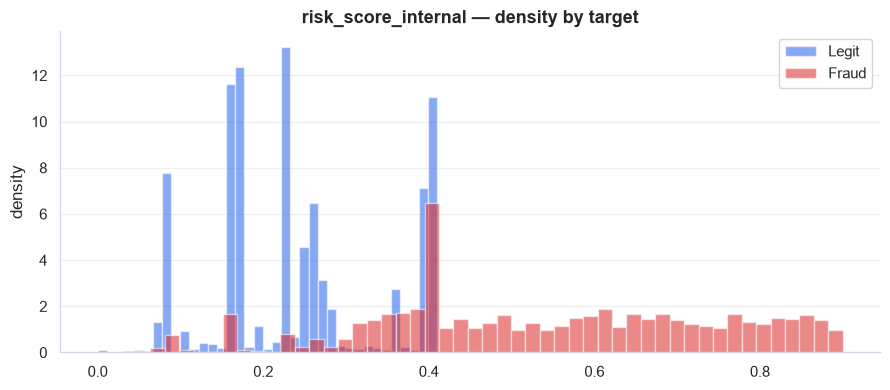

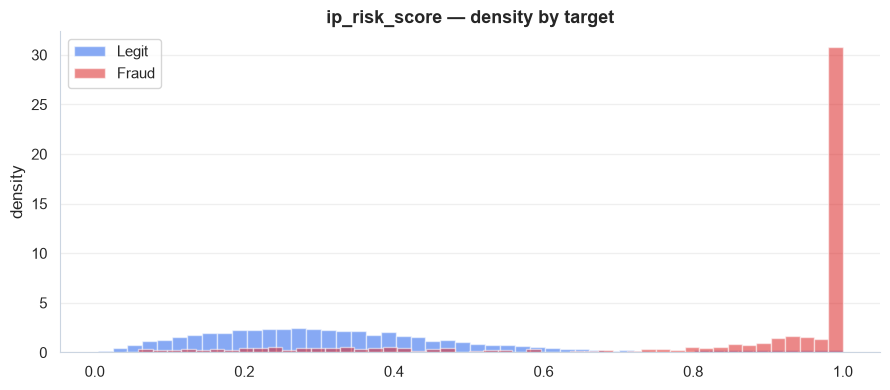

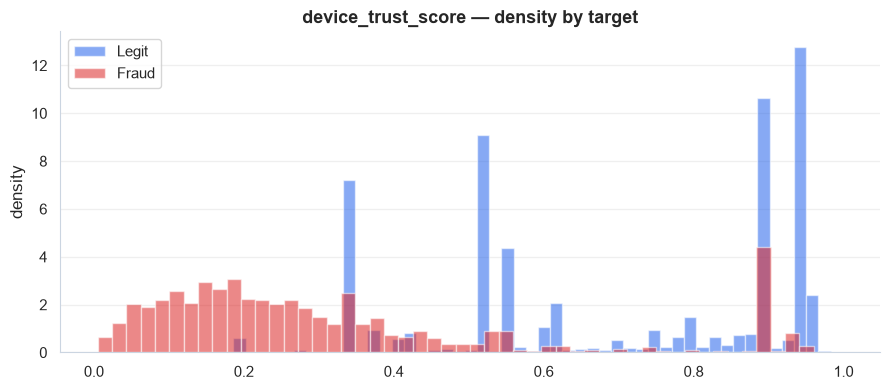

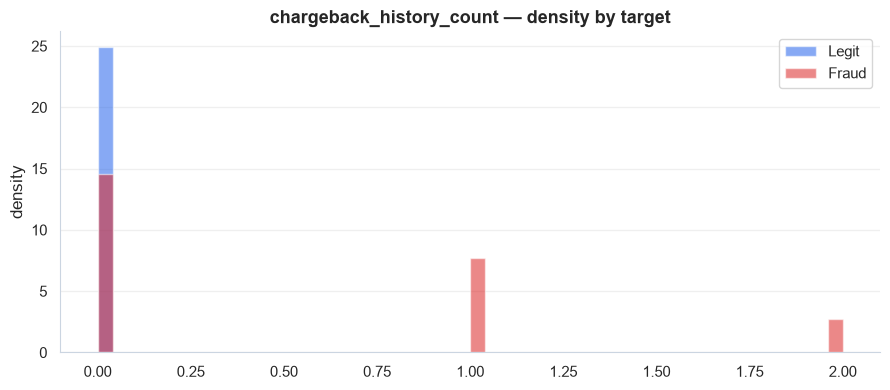

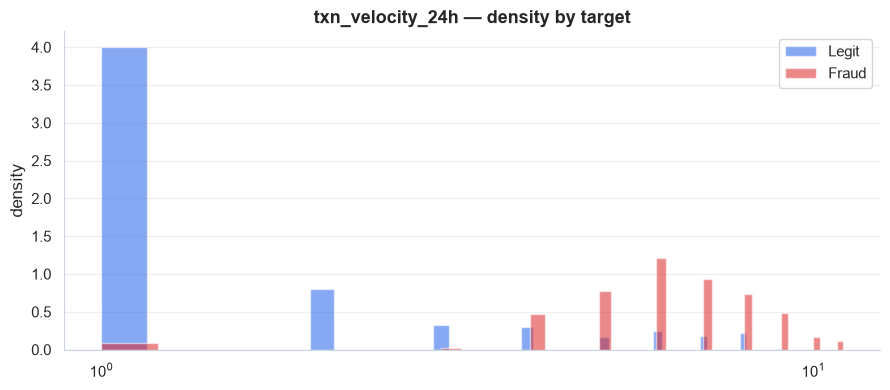

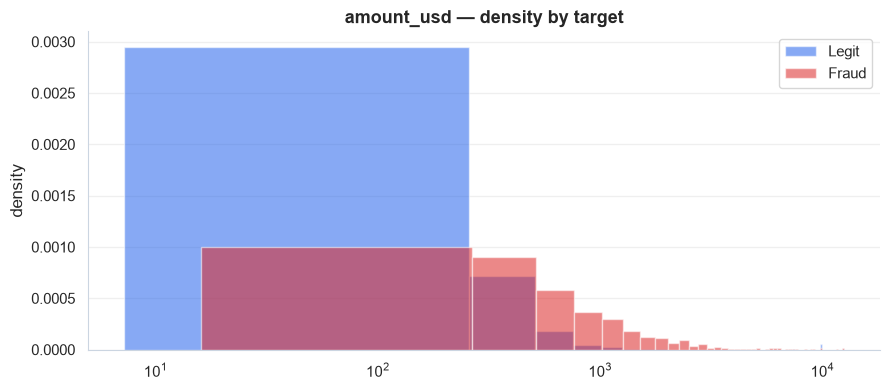

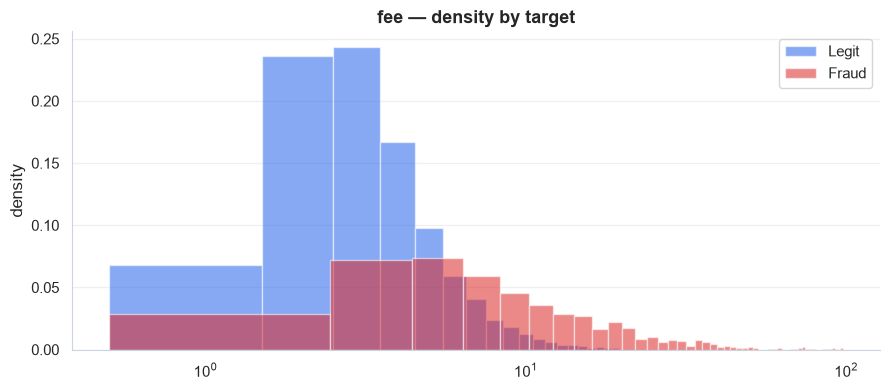

In [6]:
# numeric distributions, fraud vs legit overlayed on top of each other
def num_overlay(col, log=False):
    fig, ax = plt.subplots(figsize=(9, 4))
    for grp, color, label in [(0, LEGIT, "Legit"), (1, FRAUD, "Fraud")]:
        s = df.loc[df.is_fraud == grp, col].dropna()
        if log:
            s = s[s > 0]
        ax.hist(s, bins=50, density=True, alpha=0.55, color=color, label=label)
    if log:
        ax.set_xscale("log")
    ax.set_title(f"{col} — density by target")
    ax.set_ylabel("density")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.show()

num_overlay("account_age_days", log=True)
num_overlay("risk_score_internal", log=False)
num_overlay("ip_risk_score", log=False)
num_overlay("device_trust_score", log=False)
num_overlay("chargeback_history_count", log=False)
num_overlay("txn_velocity_24h", log=True)   # note: this one really is skewed
num_overlay("amount_usd", log=True)          # skewed
num_overlay("fee", log=True)

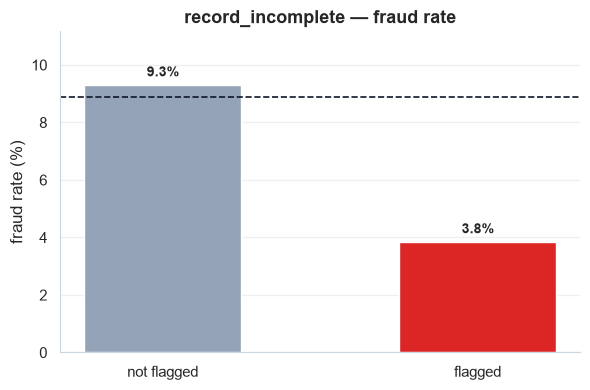

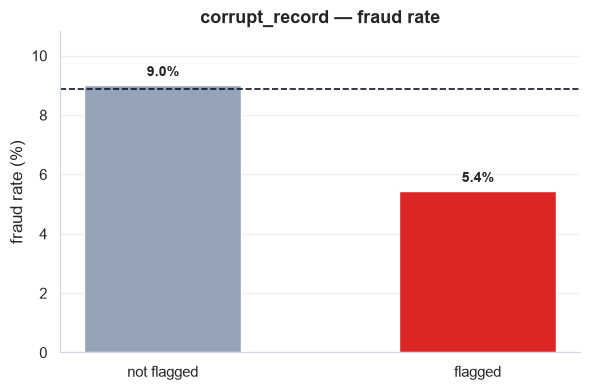

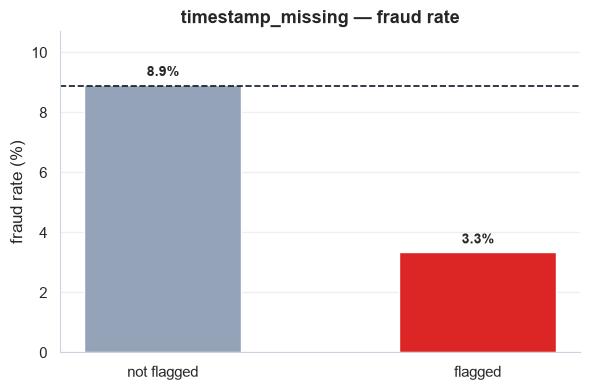

In [7]:
# derived flags we added in cleaning: do they say anything?
def flag_chart(col):
    t = df.groupby(col)["is_fraud"].agg(n="count", rate="mean")
    labels = ["not flagged", "flagged"]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, t["rate"].values*100, width=0.5,
                  color=[NEUTRAL, FRAUD])
    for bar, r in zip(bars, t["rate"].values):
        ax.text(bar.get_x() + bar.get_width()/2, r*100 + 0.3,
                f"{r*100:.1f}%", ha="center", fontweight="bold")
    ax.axhline(df.is_fraud.mean()*100, ls="--", color="#0f172a", lw=1.2)
    ax.set_ylim(0, max(t["rate"].max()*100*1.2, 8))
    ax.set_title(f"{col} — fraud rate")
    ax.set_ylabel("fraud rate (%)")
    ax.grid(axis="y", alpha=0.3)
    plt.show()

for col in ["record_incomplete", "corrupt_record", "timestamp_missing"]:
    flag_chart(col)

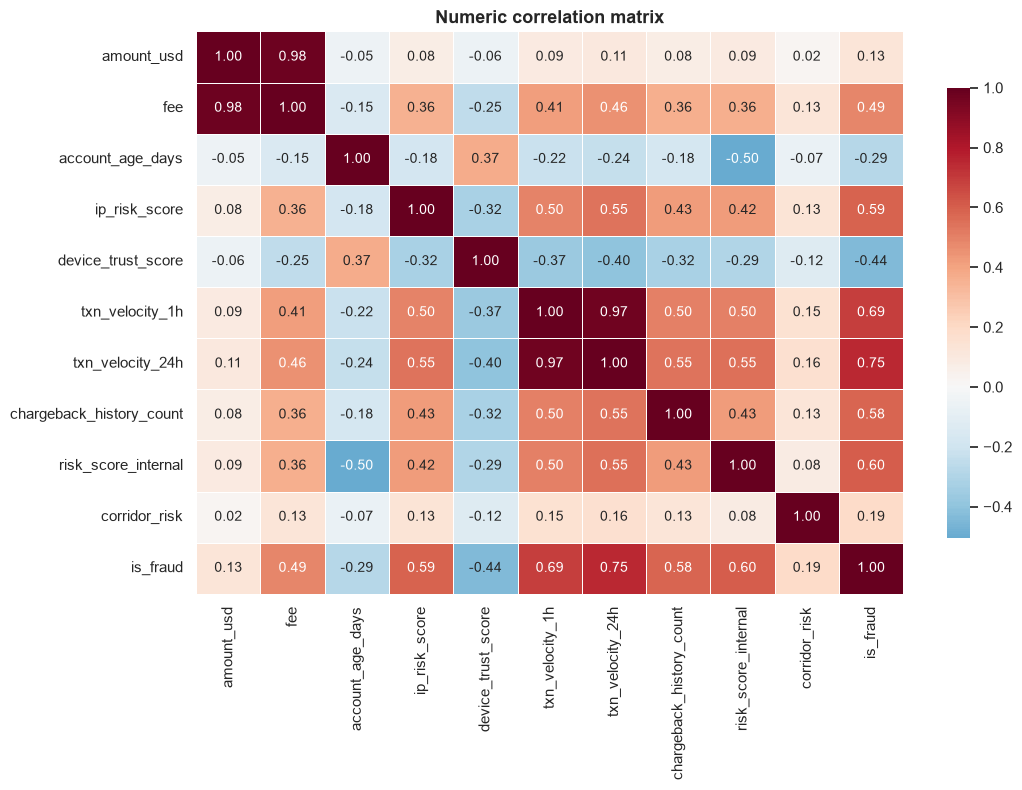

In [8]:
# correlation heatmap -- mostly me watching for leakage before I trust the numerics
num_cols = ["amount_usd", "fee", "account_age_days", "ip_risk_score",
            "device_trust_score", "txn_velocity_1h", "txn_velocity_24h",
            "chargeback_history_count", "risk_score_internal",
            "corridor_risk", "is_fraud"]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", center=0,
            cmap="RdBu_r", linewidths=0.4, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Numeric correlation matrix", fontweight="bold")
plt.show()

### The amount finding I almost missed
My early charts showed `amount_usd` as log-skewed and called it a day. Then I asked a harder question: *is there an amount band where fraud concentrates?* Turns out yes, and it's not "more money = more fraud".

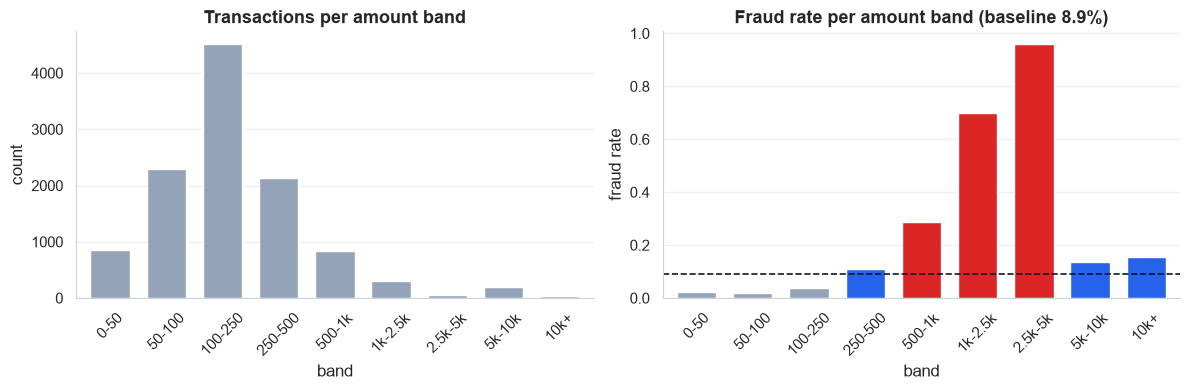

band             n  fraud    rate
0-50           851     18    2.1%
50-100       2,285     41    1.8%
100-250      4,513    168    3.7%
250-500      2,128    234   11.0%
500-1k         840    240   28.7%
1k-2.5k        307    215   70.0%
2.5k-5k         49     47   95.9%
5k-10k         192     26   13.5%
10k+            32      5   15.6%

>= $  250:  3,548 txns (31.7% of data) |   768 frauds (77.2% of all fraud) | fraud rate  21.6%
>= $  500:  1,420 txns (12.7% of data) |   534 frauds (53.7% of all fraud) | fraud rate  37.6%
>= $1,000:    580 txns ( 5.2% of data) |   293 frauds (29.4% of all fraud) | fraud rate  50.5%
>= $2,500:    273 txns ( 2.4% of data) |    78 frauds ( 7.8% of all fraud) | fraud rate  28.6%
>= $5,000:    224 txns ( 2.0% of data) |    31 frauds ( 3.1% of all fraud) | fraud rate  13.8%


In [9]:
# fraud rate by amount band -- this is the evidence for the amount_high_flag feature
bins = [-1, 50, 100, 250, 500, 1000, 2500, 5000, 10000, np.inf]
labels = ["0-50", "50-100", "100-250", "250-500", "500-1k", "1k-2.5k",
          "2.5k-5k", "5k-10k", "10k+"]
band = pd.cut(df.amount_usd, bins, labels=labels)
t = (df.assign(band=band)
       .groupby("band", observed=False)["is_fraud"]
       .agg(n="count", rate="mean"))
t = t.reindex(labels)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
t["n"].plot.bar(ax=ax0, color=NEUTRAL, width=0.7)
ax0.set_title("Transactions per amount band")
ax0.set_ylabel("count")
ax0.tick_params(axis="x", rotation=45)
ax0.grid(axis="y", alpha=0.3)

colors = [FRAUD if r >= df.is_fraud.mean()*2 else (LEGIT if r >= df.is_fraud.mean() else NEUTRAL)
          for r in t["rate"]]
t["rate"].plot.bar(ax=ax1, color=colors, width=0.7)
ax1.axhline(df.is_fraud.mean(), ls="--", color="#0f172a", lw=1.2)
ax1.set_title("Fraud rate per amount band (baseline 8.9%)")
ax1.set_ylabel("fraud rate")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", alpha=0.3)
plt.show()

print(f"{'band':<10} {'n':>7} {'fraud':>6} {'rate':>7}")
for lab in labels:
    row = t.loc[lab]
    print(f"{lab:<10} {int(row.n):>7,} {int(row.n*row.rate):>6,} {row.rate*100:>6.1f}%")
print()
for thresh in [250, 500, 1000, 2500, 5000]:
    sub = df[df.amount_usd >= thresh]
    print(f">= ${thresh:>5,}: {len(sub):>6,} txns ({len(sub)/len(df)*100:4.1f}% of data) | "
          f"{int(sub.is_fraud.sum()):>5,} frauds ({sub.is_fraud.sum()/df.is_fraud.sum()*100:4.1f}% of all fraud) | "
          f"fraud rate {sub.is_fraud.mean()*100:5.1f}%")

In [10]:
# the threshold that captures the most fraud at the lowest cost:
#   >$1k catches ~29% of fraud, but >=$250 catches 77% at ~2.4x baseline rate.
#   -> the derived feature is amount_high_flag = amount_usd >= 250
from sklearn.metrics import roc_auc_score
ok = df.amount_usd.notna()   # a few amount_usd are NaN from cleaning; drop for the sanity check
for thresh in [250, 500, 1000]:
    flag = (df.amount_usd >= thresh)[ok].astype(int)
    print(f"amount_high_flag ($>={thresh:>4}) standalone AUC: {roc_auc_score(df.is_fraud[ok], flag):.4f}")
print(f"log1p(amount) AUC: {roc_auc_score(df.is_fraud[ok], np.log1p(df.amount_usd[ok])):.4f}")
print()
# I pick $250: it's the threshold where fraud rate jumps to >2x baseline while
# still keeping 77% of the fraud in scope. Clean, explainable cut.

amount_high_flag ($>= 250) standalone AUC: 0.7497
amount_high_flag ($>= 500) standalone AUC: 0.7249
amount_high_flag ($>=1000) standalone AUC: 0.6332
log1p(amount) AUC: 0.8178



## Takeaways (written after the fact, as me)

- **Class imbalance:** 995 of 11,200 txns (8.88%) are fraud. Naive 'all legit' accuracy is ~91%, so I'll judge models on **ROC-AUC** (ranking) and **PR-AUC** (rare-class honesty) — not accuracy.
- **kyc_tier makes or breaks it:** `low` KYC is ~51.2% fraudulent vs ~2-5% for standard/enhanced. This alone splits the data, and it's the strongest category-level signal I found.
- **Behavioural flags are loud:** `location_mismatch` carries ~36% fraud rate, `new_device` ~38% — both ~4x baseline. These are the classic 'mule account' tells.
- **Cross-border corridors:** `home_country` ca/uk sit at ~15.3% / ~13.4% fraud (vs us at ~6.7%); `channel web` is ~16.3% vs mobile ~4.7%.
- **Amount has a fraud 'sweet spot', not a monotonic rule:** fraud rate rises from ~2% under $100 to ~29% at $500-1k, peaks ~70% at $1k-2.5k, ~96% at $2.5k-5k, then *crashes* to ~13-16% above $5k. So `log1p(amount)` alone hides the story → I added `amount_high_flag` (amount >= $250) as a derived boolean — it captures 77% of all fraud at ~2.4x baseline rate.
- **Leakage caution:** `risk_score_internal` and `chargeback_history_count` correlate strongly with the target. I flagged these early and tested in modelling whether they're genuine behaviour or the answer—see modelling notebook.
- **Incompleteness argues *against* fraud (surprise):** rows flagged `record_incomplete` run ~3.8% fraud vs 9.3% un-flagged — probably half-finished attempts that never cause damage. Keeping the flag but remembering the direction.
- **Transformations:** I log-scale skewed numerics (amount, fee, account_age_days, velocities). On encoding: linear models *need* one-hot; tree models (RF/XGB) don't strictly, but I bake the **same** one-hot preprocessor into every model so all candidates share one flat 44-feature space and one serving contract — that trade-off is deliberate.